##Install required packages

In [ ]:
# Colab cell 1
!pip install -q kaggle tensorflow matplotlib


##Upload kaggle.json (Kaggle API token)

In [ ]:
# Colab cell 2 - run this and upload kaggle.json when prompted
from google.colab import files
uploaded = files.upload()  # choose kaggle.json from your machine

# move to correct place and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# confirm kaggle works
!kaggle --version


Saving kaggle.json to kaggle (1).json
Kaggle API 1.7.4.5


##Download + unzip the PlantVillage dataset from Kaggle

In [ ]:
# Colab cell 3 - download & unzip
# Download dataset (slug: abdallahalidev/plantvillage-dataset)
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/

# Unzip any downloaded zip(s) into /content/plant_dataset
!mkdir -p /content/plant_dataset
!unzip -q /content/*.zip -d /content/plant_dataset

# Show top-level files/folders found
!ls -la /content/plant_dataset | sed -n '1,120p'


Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
 99% 2.02G/2.04G [00:13<00:00, 234MB/s]
100% 2.04G/2.04G [00:13<00:00, 163MB/s]
total 12
drwxr-xr-x 3 root root 4096 Sep  2 06:34 .
drwxr-xr-x 1 root root 4096 Sep  2 06:34 ..
drwxr-xr-x 5 root root 4096 Sep  2 06:35 plantvillage dataset


##Create a small sample dataset (3 largest classes) — quick training

In [ ]:
# Colab cell 4 - create small subset (3 classes)
import os, shutil, random
from glob import glob
random.seed(42)

ORIG_ROOT = '/content/plant_dataset'
SMALL_ROOT = '/content/plant_dataset_small'
os.makedirs(SMALL_ROOT, exist_ok=True)

# Find directories that contain images
def find_image_dirs(root):
    image_dirs = []
    for dirpath, dirnames, filenames in os.walk(root):
        # consider only directories that have image files
        if any(fname.lower().endswith(('.jpg','.jpeg','.png')) for fname in filenames):
            # Check if the directory contains a significant number of images to be considered a class directory
            if len([f for f in filenames if f.lower().endswith(('.jpg','.jpeg','.png'))]) > 10: # threshold of 10 images to consider it a class dir
                image_dirs.append(dirpath)
    return sorted(image_dirs)


image_dirs = find_image_dirs(ORIG_ROOT)
print(f"Found {len(image_dirs)} possible image dirs. Sample: {image_dirs[:5]}")

# compute counts
counts = []
for d in image_dirs:
    files = [f for f in os.listdir(d) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    counts.append((d, len(files)))
counts = sorted(counts, key=lambda x: x[1], reverse=True)

# pick top N classes (change N to your liking)
N = 3
chosen = counts[:N]
print("Chosen classes (path, count):")
for p,c in chosen:
    print(os.path.basename(p), c)

# create train/valid splits and copy files
train_ratio = 0.8
for class_path, cnt in chosen:
    class_name = os.path.basename(class_path)
    src_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(src_files)
    split = int(train_ratio * len(src_files))
    train_files = src_files[:split]
    valid_files = src_files[split:]

    train_dst = os.path.join(SMALL_ROOT, 'train', class_name)
    valid_dst = os.path.join(SMALL_ROOT, 'valid', class_name)
    os.makedirs(train_dst, exist_ok=True)
    os.makedirs(valid_dst, exist_ok=True)

    for fname in train_files:
        shutil.copy(os.path.join(class_path, fname), os.path.join(train_dst, fname))
    for fname in valid_files:
        shutil.copy(os.path.join(class_path, fname), os.path.join(valid_dst, fname))

print("Small dataset created at:", SMALL_ROOT)
!find /content/plant_dataset_small -maxdepth 2 -type d -print

Found 114 possible image dirs. Sample: ['/content/plant_dataset/plantvillage dataset/color/Apple___Apple_scab', '/content/plant_dataset/plantvillage dataset/color/Apple___Black_rot', '/content/plant_dataset/plantvillage dataset/color/Apple___Cedar_apple_rust', '/content/plant_dataset/plantvillage dataset/color/Apple___healthy', '/content/plant_dataset/plantvillage dataset/color/Blueberry___healthy']
Chosen classes (path, count):
Orange___Haunglongbing_(Citrus_greening) 5507
Orange___Haunglongbing_(Citrus_greening) 5507
Orange___Haunglongbing_(Citrus_greening) 5507
Small dataset created at: /content/plant_dataset_small
/content/plant_dataset_small
/content/plant_dataset_small/valid
/content/plant_dataset_small/valid/segmented
/content/plant_dataset_small/valid/Orange___Haunglongbing_(Citrus_greening)
/content/plant_dataset_small/valid/grayscale
/content/plant_dataset_small/valid/color
/content/plant_dataset_small/train
/content/plant_dataset_small/train/segmented
/content/plant_dataset_

##Data generators (uses MobileNetV2 preprocess_input)

In [ ]:
# Colab cell 5 - data generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_dir = '/content/plant_dataset_small/train'
valid_dir = '/content/plant_dataset_small/valid'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=20,
                                   horizontal_flip=True,
                                   zoom_range=0.15)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 9684 images belonging to 4 classes.
Found 3078 images belonging to 4 classes.


##Build the model (MobileNetV2 transfer learning)

In [ ]:
# Check number of classes in train_gen
num_classes = train_gen.num_classes
print("Number of classes:", num_classes)

# Then rebuild the model last layer
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')  # <- use num_classes
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Number of classes: 4


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##Train (fast: small number of epochs)

In [ ]:
# Colab cell 7 - train
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

EPOCHS = 8
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/8
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - accuracy: 0.9223 - loss: 0.1990

303/303 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.9225 - loss: 0.1985 - val_accuracy: 1.0000 - val_loss: 1.3994e-04
Epoch 2/8
303/303 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 1.0000 - loss: 3.8410e-04 - val_accuracy: 1.0000 - val_loss: 7.3241e-06
Epoch 3/8
303/303 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 1.0000 - loss: 7.0153e-05 - val_accuracy: 1.0000 - val_loss: 1.9819e-06
Epoch 4/8
303/303 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 1.0000 - loss: 5.4330e-05 - val_accuracy: 1.0000 - val_loss: 8.8109e-07
Epoch 5/8
303/303 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - accuracy: 1.0000 - loss: 2.9117e-05 - val_accuracy: 1.0000 - val_loss: 4.7877e-07
Epoch 6/8
303/303 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 1.0000 - loss: 2.2887e-05 - val_accuracy: 1.0000 - val_loss: 2.7792e-07
Epoch 7/8
303/303 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 1.0000 - loss: 2.0920e-05 - val_accuracy: 1.0000 - val_loss: 1.7037e-07
Epoch 8/8
303/303 ━━━━━━━━━━━━━━━━━━━━ 396s 1s/step - accuracy

##Plot accuracy & loss (Matplotlib)

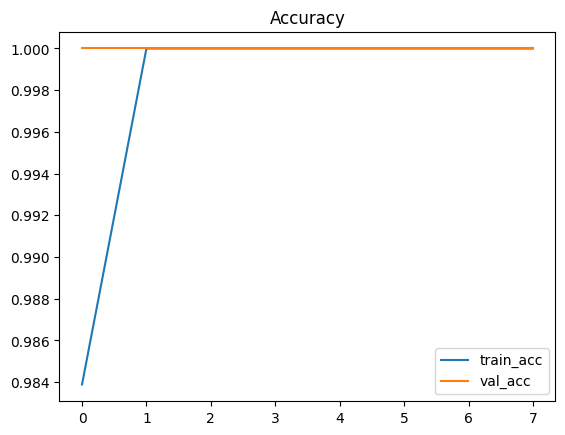

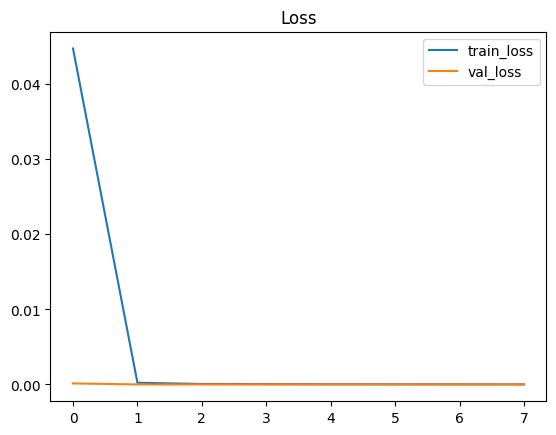

In [ ]:
# Colab cell 8 - plots
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.show()


##Save / Load best model

In [ ]:
# Colab cell 9 - save/load
model.save('plantshieldnet_mobilenet_full.h5')       # full model
# To load later:
# from tensorflow.keras.models import load_model
# model = load_model('best_model.h5')


##Inference on a new image (upload & predict)

In [ ]:
# Colab cell 10 - test on your image
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

# Upload an image from your computer
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=IMG_SIZE)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
# apply MobileNetV2 preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
x = preprocess_input(x)

pred = model.predict(x)[0]
pred_idx = int(np.argmax(pred))
inv_map = {v:k for k,v in train_gen.class_indices.items()}
print("Predicted class:", inv_map[pred_idx])
print("Confidence:", float(np.max(pred)))


Saving 0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Scab 3417.JPG to 0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Scab 3417.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Predicted class: Orange___Haunglongbing_(Citrus_greening)
Confidence: 0.999988317489624


In [ ]:
# Colab cell 11 - fine-tuning (optional)
base_model.trainable = True
# Fine-tune from this layer onwards (tweak)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

history_fine = model.fit(train_gen, validation_data=valid_gen, epochs=5, callbacks=callbacks)


Epoch 1/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - accuracy: 1.0000 - loss: 1.5795e-05 - val_accuracy: 1.0000 - val_loss: 5.0000e-08
Epoch 2/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 1.0000 - loss: 2.0465e-06 - val_accuracy: 1.0000 - val_loss: 3.3733e-08
Epoch 3/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - accuracy: 1.0000 - loss: 1.3976e-06 - val_accuracy: 1.0000 - val_loss: 2.0527e-08
Epoch 4/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - accuracy: 1.0000 - loss: 6.9989e-07 - val_accuracy: 1.0000 - val_loss: 1.6073e-08
Epoch 5/5
303/303 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 1.0000 - loss: 3.9098e-07 - val_accuracy: 1.0000 - val_loss: 8.0945e-09
